### GPT ARCHITECTURE PART 3: FEEDFORWARD NEURAL NETWORK WITH GELU ACTIVATION

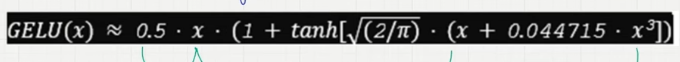

In [2]:
import torch
from torch import nn
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * 
            (x + 0.044715 * torch.pow(x, 3))
        ))

To get an idea of what this GELU function looks like and how it compares to the ReLU function, let's plot these functions side by side:

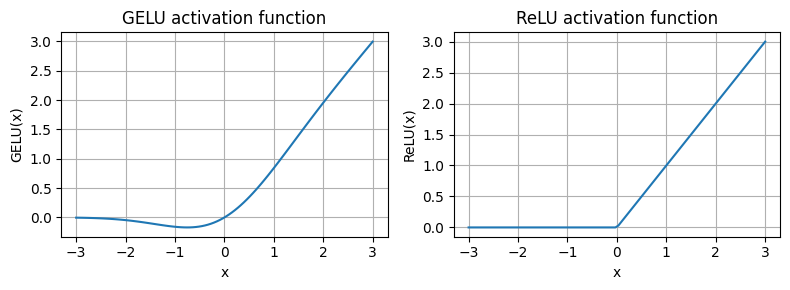

In [3]:
import matplotlib.pyplot as plt

gelu, relu = GELU(), nn.ReLU()

# Some sample data
x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)

plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)

plt.tight_layout()
plt.show()


As we can see in the resulting plot, ReLU is a piecewise linear function that
outputs the input directly if it is positive; otherwise, it outputs zero. 

GELU is a smooth, nonlinear function that approximates ReLU but with a non-zero gradient for negative values.

The smoothness of GELU, as shown in the above figure, can lead to better optimization properties during training, as it allows for more nuanced adjustments to the model's parameters.

In contrast, ReLU has a sharp corner at zero, which can sometimes make optimization harder, especially in networks that are very deep or have complex architectures.

Moreover, unlike RELU, which outputs zero for any negative input, GELU allows for a small, non-zero output for negative values.

This characteristic means that during the training process, neurons that receive negative input can still contribute to the learning process, albeit to a lesser extent than positive inputs.

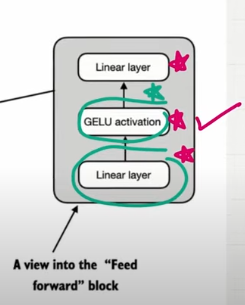

We have seen the GELU function present inside the feed forward, what about the two linear layers which are also present. 

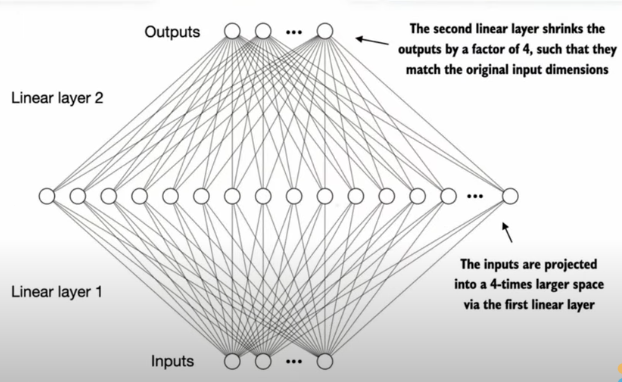

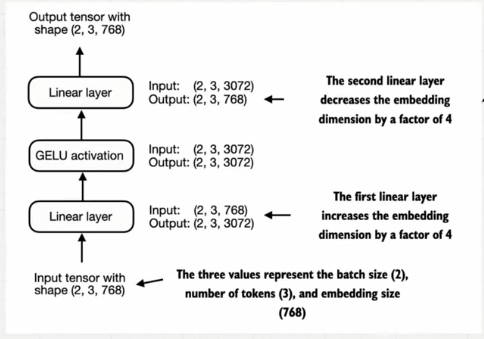

In [5]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 1024, # Context length
    "emb_dim": 768,         # Embedding dimension
    "n_heads": 12,          # Number of attention heads
    "n_layers": 12,         # Number of layers
    "drop_rate": 0.1,       # Dropout rate
    "qkv_bias": False       # Query-Key-Value bias
}

In [7]:
#lets code the feed forward layer, 
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * 
            (x + 0.044715 * torch.pow(x, 3))
        ))

class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential( #sequential is a pytorch for stacking and chaining the layers toghther to create a nn
            nn.Linear(cfg["emb_dim"], 4 * cfg['emb_dim']),  #expands four times the dimension
            #input to the layer is the org embed dim, while output is 4 times the original dim 
            GELU(), #activation 
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"])  #contracts back to original by reducing 4 times
            #input is 4 times the org dim, as given by the prev linear layer and output is 4 times shrinked dimenension equal to the org.
        )
    
    def forward(self, x):
        return self.layers(x)

In [6]:
GPT_CONFIG_124M['emb_dim']

768

In [9]:
ffn = FeedForward(GPT_CONFIG_124M)
x = torch.rand(2, 3, 768)
out = ffn(x)
print(out)
print()
print(out.shape)

tensor([[[-0.1071,  0.0928, -0.1017,  ..., -0.1177,  0.1615, -0.1470],
         [-0.2176,  0.1396, -0.0400,  ..., -0.1121,  0.0425, -0.1563],
         [-0.1043,  0.1811, -0.0481,  ..., -0.0478, -0.0413, -0.0649]],

        [[-0.1549,  0.0867, -0.0788,  ..., -0.0982,  0.0750, -0.1498],
         [-0.1550,  0.1269, -0.0475,  ..., -0.1018,  0.0568, -0.2064],
         [-0.0586,  0.1457,  0.0132,  ..., -0.0545,  0.0011, -0.0626]]],
       grad_fn=<ViewBackward0>)

torch.Size([2, 3, 768])


The FeedForward module we implemented in this section plays a crucial role in enhancing the model's ability to learn from and generalize the data.

Although the input and output dimensions of this module are the same, it internally expands the embedding dimension into a higher-dimensional space through the first linear layer.

This expansion is followed by a non-linear GELU activation, and then a contraction back to the original dimension with the second linear transformation.

Such a design allows for the exploration of a richer representation space.

Moreover, the uniformity in input and output dimensions simplifies the architecture by enabling the stacking of multiple layers, as we will do later, without the need to adjust dimensions between them, thus making the model more scalable.